# M11.10 — Predictor bias and compression

Compare exactly **M10 z-score**, **M11 G1 z-score**, and **M11 G1 no-z**, using saved test predictions only.

Questions: does M11 retain regression to the mean; does removing input z-score reduce compression or extreme-target bias; and does `chi_eff` still contract toward zero?

M10 → M11 is descriptive: training size (400k versus 20k) and test population (30k versus 2k) differ. It cannot isolate a noise-domain effect. The paired M11 G1 z-score → no-z contrast addresses the normalization question.

Reuse: [M10 notebook 11, §§4–5](../11_mondrian_m10_inputzscore_500k_final.ipynb), `src.models.evaluate`, and the residual conventions in `src.models.plots`. No training, inference, conformal analysis or embeddings are used.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

PROJECT_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "src/paths.py").is_file())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from src.paths import resolve_data_root
from src.models.evaluate import inverse_standardize, regression_metrics

DATA_ROOT = resolve_data_root(cli_data_root="/data/vserrano/cbc_pe_data")
FILES = {
    "M10 z-score": DATA_ROOT / "results/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000/m10_inputzscore_500k_cal_test_predictions_embeddings.npz",
    "M11 G1 z-score": DATA_ROOT / "results/m11_6_domains/m11_6_G1_to_G1_test_predictions_embeddings.npz",
    "M11 G1 no-z": DATA_ROOT / "results/m11_9_noz_domains/m11_9_G1_to_G1_noz_test_predictions_embeddings.npz",
}
LABELS = ["chirp_mass", "total_mass", "chi_eff"]
UNITS = {"chirp_mass": "solar masses", "total_mass": "solar masses", "chi_eff": "dimensionless"}
CASES = list(FILES)

## Saved arrays and comparison contract

Load only test predictions, targets, indices, label scalers and string provenance. Inverse-standardize each case using its own saved train-only scaler. Require matching M11 indices, targets and scalers; indices refer to each case's dataset and must not be used to pair M10 with M11.

M11 G1 z-score was persisted already normalized; no-z was persisted before that final normalization. No input transformation is performed here.

In [2]:
def load_case(path):
    with np.load(path, allow_pickle=False) as data:
        names = [str(x) for x in data["label_names"].tolist()]
        assert names == LABELS, (path, names)
        item = {key: np.asarray(data[key], dtype=np.float64) for key in
                ["pred_test", "y_test", "y_mean", "y_std"]}
        item["idx"] = np.asarray(data["idx_test"], dtype=np.int64)
        item["provenance"] = {key: str(data[key].item()) for key in
                              ["checkpoint_file", "dataset_path", "split_path", "label_stats_path"]}
    assert item["pred_test"].shape == item["y_test"].shape == (len(item["idx"]), len(LABELS))
    assert item["y_mean"].shape == item["y_std"].shape == (len(LABELS),)
    assert all(np.isfinite(item[key]).all() for key in ["pred_test", "y_test", "y_mean", "y_std"])
    assert (item["y_std"] > 0).all()
    assert len(np.unique(item["idx"])) == len(item["idx"])
    item["pred"] = inverse_standardize(item["pred_test"], item["y_mean"], item["y_std"])
    item["true"] = inverse_standardize(item["y_test"], item["y_mean"], item["y_std"])
    return item

loaded = {case: load_case(path) for case, path in FILES.items()}
z, noz = loaded["M11 G1 z-score"], loaded["M11 G1 no-z"]
for key in ["idx", "y_test", "y_mean", "y_std", "true"]:
    assert np.array_equal(z[key], noz[key]), f"M11 pairing mismatch: {key}"

display(pd.DataFrame([{
    "case": case, "test_shape": item["pred"].shape,
    "prediction_file": FILES[case].name,
    "checkpoint": Path(item["provenance"]["checkpoint_file"]).name,
} for case, item in loaded.items()]))
print("M11 test indices, targets and train-only scalers match exactly.")

M11 test indices, targets and train-only scalers match exactly.


,case,test_shape,prediction_file,checkpoint
0,M10 z-score,"(30000, 3)",m10_inputzscore_500k_cal_test_predictions_embe...,bbh_processed_4s_seobnrv4opt_snr10-25_n500_000...
1,M11 G1 z-score,"(2000, 3)",m11_6_G1_to_G1_test_predictions_embeddings.npz,m11_6_domains_SimpleCNN_ResidualDilated_M11_6_...
2,M11 G1 no-z,"(2000, 3)",m11_9_G1_to_G1_noz_test_predictions_embeddings...,m11_9_noz_domains_SimpleCNN_ResidualDilated_M1...


## Physical metrics and common bins

Residual = prediction − truth. Fit `prediction = slope × truth + intercept`; report Pearson correlation and `std(prediction) / std(truth)` using NumPy's default population standard deviation. Absolute-error q50/q90/q95 use default linear interpolation.

Ten common bins per label use the paired M11 true-target deciles. Bins are left-inclusive/right-exclusive, except the last includes its upper edge. Empty bins retain count zero and undefined bias. Samples outside these edges remain in global metrics and plots but not in the binned means; their counts are reported separately. Binned **bias is the mean signed residual**, not the median trend used in M10 notebook 11.

In [3]:
metric_rows = []
for case, item in loaded.items():
    base = regression_metrics(item["true"], item["pred"], LABELS).set_index("label")
    for j, label in enumerate(LABELS):
        true, pred = item["true"][:, j], item["pred"][:, j]
        slope, intercept = np.polyfit(true, pred, deg=1)
        q50, q90, q95 = np.quantile(np.abs(pred - true), [0.50, 0.90, 0.95])
        metric_rows.append({
            "case": case, "label": label, "n": len(true),
            "RMSE": base.loc[label, "RMSE"], "MAE": base.loc[label, "MAE"],
            "bias": base.loc[label, "bias"], "slope": slope, "intercept": intercept,
            "correlation": np.corrcoef(true, pred)[0, 1],
            "std_pred_over_true": np.std(pred) / np.std(true),
            "q50": q50, "q90": q90, "q95": q95,
        })
metrics = pd.DataFrame(metric_rows)

edges_by_label = {label: np.quantile(z["true"][:, j], np.linspace(0, 1, 11))
                  for j, label in enumerate(LABELS)}
bin_rows, outside_rows = [], []
for j, label in enumerate(LABELS):
    edges = edges_by_label[label]
    assert np.all(np.diff(edges) > 0), f"Repeated decile edges for {label}"
    for case, item in loaded.items():
        true, pred = item["true"][:, j], item["pred"][:, j]
        outside_rows.append({"label": label, "case": case,
                             "below": int(np.sum(true < edges[0])),
                             "above": int(np.sum(true > edges[-1]))})
        for b, (left, right) in enumerate(zip(edges[:-1], edges[1:])):
            mask = (true >= left) & ((true <= right) if b == 9 else (true < right))
            bin_rows.append({
                "label": label, "case": case, "bin": b + 1,
                "left": left, "right": right, "center": (left + right) / 2,
                "count": int(mask.sum()),
                "bias": np.mean((pred - true)[mask]) if mask.any() else np.nan,
            })
binned = pd.DataFrame(bin_rows)
outside = pd.DataFrame(outside_rows)
for (label, case), group in binned.groupby(["label", "case"]):
    excluded = outside[(outside.label == label) & (outside.case == case)]
    assert group["count"].sum() + excluded[["below", "above"]].to_numpy().sum() == len(loaded[case]["idx"])
    
for label in LABELS:
    print(f"{label} — common bins ({UNITS[label]})")
    display(binned[binned.label == label].pivot(
        index=["bin", "left", "right"], columns="case", values=["count", "bias"]
    ).reindex(columns=pd.MultiIndex.from_product([["count", "bias"], CASES])).round(4))
print("Samples outside the M11 bin range (retained in global metrics and plots):")
display(outside.set_index(["label", "case"]))

chirp_mass — common bins (solar masses)
total_mass — common bins (solar masses)
chi_eff — common bins (dimensionless)
Samples outside the M11 bin range (retained in global metrics and plots):


count                 ...           bias            
                        M10 z-score M11 G1 z-score  ... M11 G1 z-score M11 G1 no-z
bin left      right                                 ...                           
1   5.685100  16.449475      3059.0          200.0  ...         2.2298      2.9135
2   16.449475 21.405036      2976.0          200.0  ...         2.7057      4.1521
3   21.405036 26.221686      2916.0          200.0  ...         1.2850      2.5426
4   26.221686 30.542413      2606.0          200.0  ...         0.9311      1.8416
5   30.542413 35.719137      3130.0          200.0  ...        -0.0243      1.0307
6   35.719137 41.050877      3004.0          200.0  ...         0.0856      0.9545
7   41.050877 46.362429      2976.0          200.0  ...        -0.5498     -0.3910
8   46.362429 52.957346      3194.0          200.0  ...        -1.9701     -1.9676
9   52.957346 60.913574      3099.0          200.0  ...        -2.7566     -3.2747
10  60.913574 77.636283      3021.0          200.0  ...        -5.4017     -6.3405

[10 rows x 6 columns]

count                 ...           bias            
                          M10 z-score M11 G1 z-score  ... M11 G1 z-score M11 G1 no-z
bin left       right                                  ...                           
1   13.172568  48.308782       2977.0          200.0  ...         3.8283      7.2741
2   48.308782  64.523293       3196.0          200.0  ...        -0.2867      2.8612
3   64.523293  76.032129       2926.0          200.0  ...        -1.4818      1.0397
4   76.032129  85.582344       2704.0          200.0  ...        -1.0085      1.3157
5   85.582344  94.835129       3003.0          200.0  ...        -1.3731      0.5283
6   94.835129  103.142509      2867.0          200.0  ...        -0.5532      0.0188
7   103.142509 113.537981      3074.0          200.0  ...         0.3728      0.4041
8   113.537981 125.084324      2962.0          200.0  ...        -1.3551     -1.3396
9   125.084324 141.593539      3182.0          200.0  ...        -3.1009     -4.4252
10  141.593539 178.362186      3089.0          200.0  ...       -10.9767    -12.4312

[10 rows x 6 columns]

count                 ...           bias            
                        M10 z-score M11 G1 z-score  ... M11 G1 z-score M11 G1 no-z
bin left      right                                 ...                           
1   -0.984568 -0.617935      2763.0          200.0  ...         0.2279      0.2511
2   -0.617935 -0.440347      2715.0          200.0  ...         0.1257      0.1375
3   -0.440347 -0.286561      2966.0          200.0  ...         0.0939      0.1002
4   -0.286561 -0.135670      3230.0          200.0  ...         0.0139      0.0030
5   -0.135670 -0.000030      3083.0          200.0  ...        -0.0291     -0.0278
6   -0.000030  0.144586      3445.0          200.0  ...        -0.0607     -0.0479
7    0.144586  0.271431      2787.0          200.0  ...        -0.0357     -0.0412
8    0.271431  0.424996      3094.0          200.0  ...        -0.1013     -0.0729
9    0.424996  0.601102      2935.0          200.0  ...        -0.1457     -0.1336
10   0.601102  0.937068      2890.0          200.0  ...        -0.2321     -0.2273

[10 rows x 6 columns]

below  above
label      case                        
chirp_mass M10 z-score        14      5
           M11 G1 z-score      0      0
           M11 G1 no-z         0      0
total_mass M10 z-score        15      5
           M11 G1 z-score      0      0
           M11 G1 no-z         0      0
chi_eff    M10 z-score         6     86
           M11 G1 z-score      0      0
           M11 G1 no-z         0      0

## Truth/prediction and residual structure

One figure per label: columns follow the three cases; the top row shows truth versus prediction, and the bottom row shows signed residuals and common-bin mean bias. Axes are shared within each row and include all samples. Hexbin colors show within-panel log counts; populations have different sizes, so color intensity is not a cross-case performance metric.

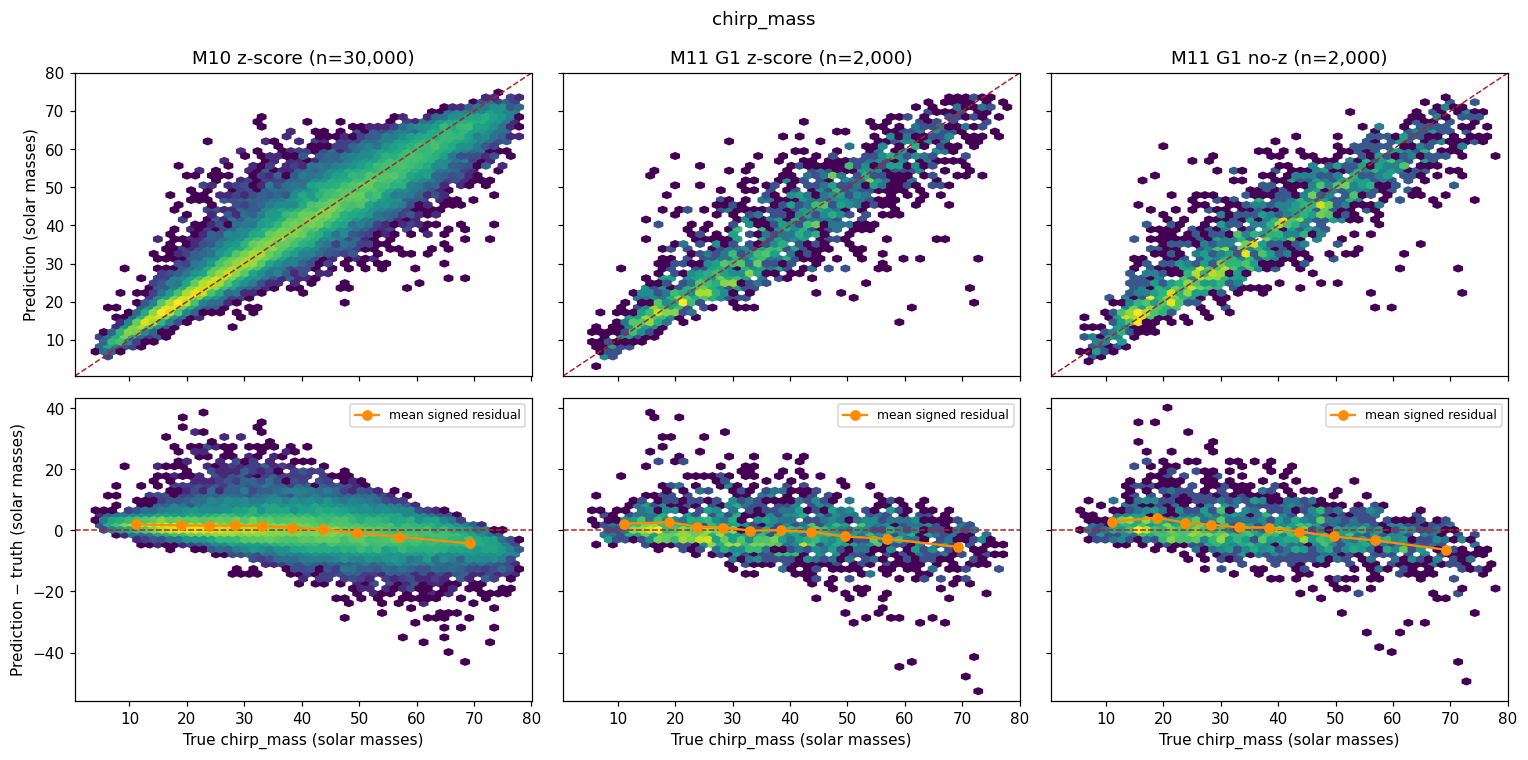

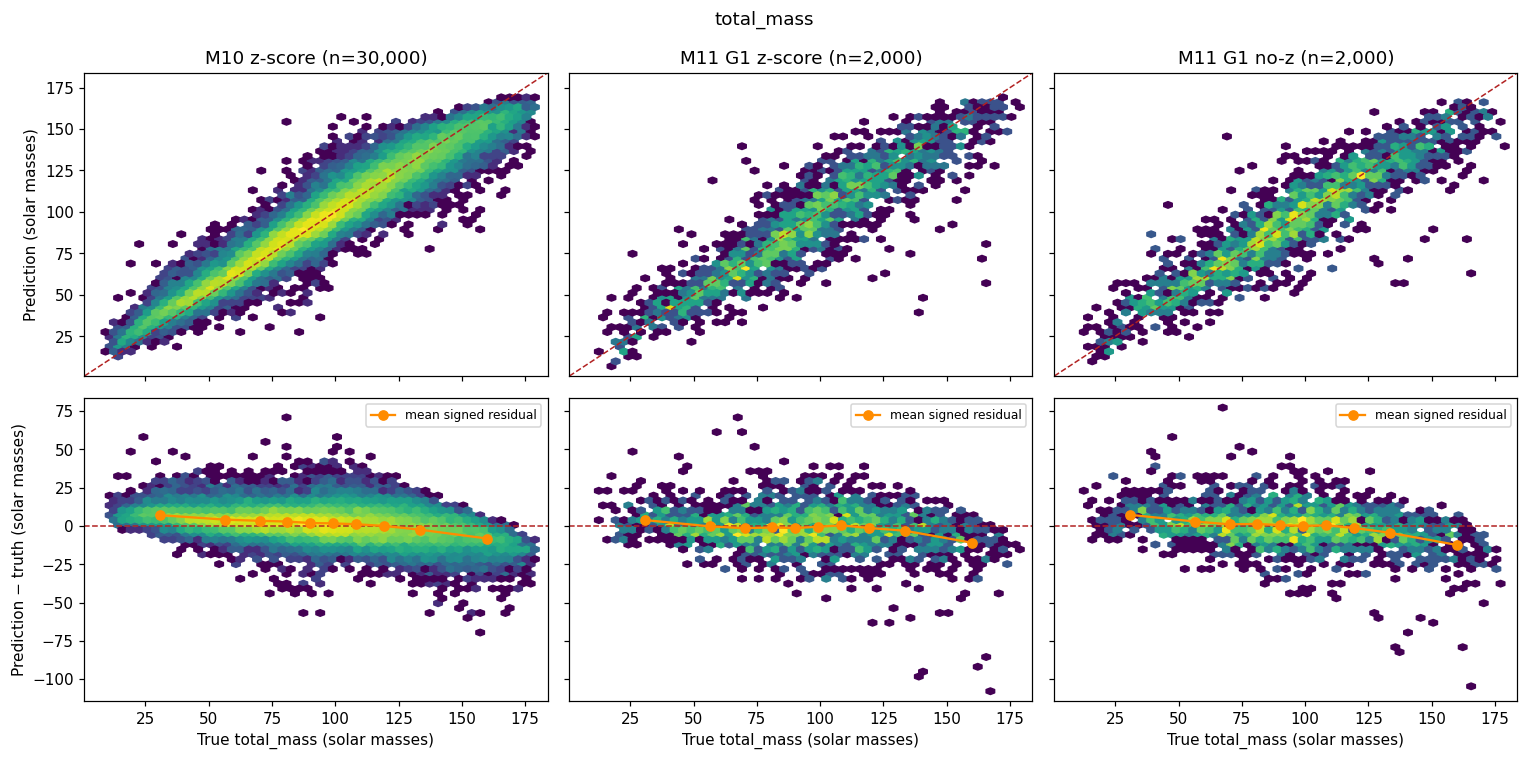

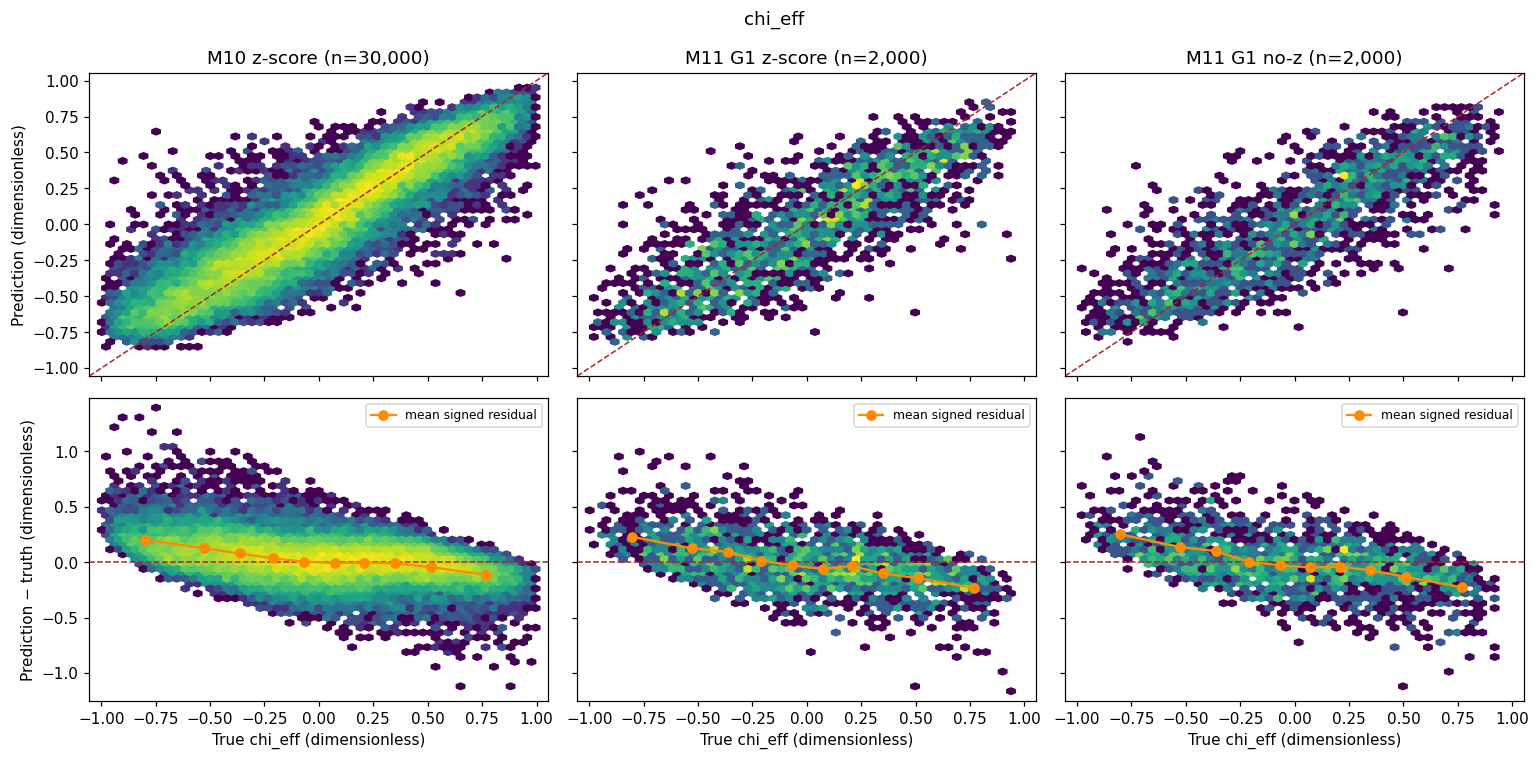

In [4]:
for j, label in enumerate(LABELS):
    fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True, sharey="row")
    values = np.concatenate([item[key][:, j] for item in loaded.values() for key in ["true", "pred"]])
    lo, hi = values.min(), values.max()
    pad = 0.03 * (hi - lo)
    limits = (lo - pad, hi + pad)
    residuals = np.concatenate([item["pred"][:, j] - item["true"][:, j] for item in loaded.values()])
    rpad = 0.03 * (residuals.max() - residuals.min())
    rlimits = (residuals.min() - rpad, residuals.max() + rpad)
    for col, (case, item) in enumerate(loaded.items()):
        true, pred = item["true"][:, j], item["pred"][:, j]
        top, bottom = axes[:, col]
        top.hexbin(true, pred, gridsize=55, bins="log", mincnt=1, cmap="viridis",
                   extent=(*limits, *limits))
        top.plot(limits, limits, "--", color="firebrick", linewidth=1)
        top.set_title(f"{case} (n={len(true):,})")
        top.set_xlim(limits)
        top.set_ylim(limits)
        bottom.hexbin(true, pred - true, gridsize=55, bins="log", mincnt=1, cmap="viridis",
                      extent=(*limits, *rlimits))
        bottom.axhline(0, linestyle="--", color="firebrick", linewidth=1)
        sub = binned[(binned.label == label) & (binned.case == case)]
        bottom.plot(sub["center"], sub["bias"], "o-", color="darkorange", label="mean signed residual")
        bottom.set_ylim(rlimits)
        bottom.set_xlabel(f"True {label} ({UNITS[label]})")
        bottom.legend(fontsize=8)
    axes[0, 0].set_ylabel(f"Prediction ({UNITS[label]})")
    axes[1, 0].set_ylabel(f"Prediction − truth ({UNITS[label]})")
    fig.suptitle(label)
    fig.tight_layout()
    plt.show()
    plt.close(fig)

## Compact summary

All errors, biases and intercepts are in physical units: solar masses for mass labels and dimensionless for `chi_eff`. Slopes, correlations and standard-deviation ratios are dimensionless. The table uses all test samples, including any outside the shared bin range.

In [5]:
summary = metrics.set_index(["label", "case"]).reindex(
    pd.MultiIndex.from_product([LABELS, CASES], names=["label", "case"])
)
with pd.option_context("display.max_columns", None, "display.width", 180):
    display(summary.round(4))

n     RMSE      MAE    bias   slope  intercept  correlation  std_pred_over_true     q50      q90      q95
label      case                                                                                                                         
chirp_mass M10 z-score     30000   4.9499   3.4164  0.2179  0.8883     4.4071       0.9545              0.9307  2.2927   7.7802  10.2785
           M11 G1 z-score   2000   7.4955   5.1715 -0.3465  0.8588     4.9124       0.8922              0.9626  3.6697  11.1700  14.7180
           M11 G1 no-z      2000   7.3946   5.1738  0.1461  0.8179     6.9304       0.8926              0.9162  3.5962  11.3907  15.0256
total_mass M10 z-score     30000   9.3697   6.9874  1.0785  0.8885    11.6872       0.9643              0.9214  5.4049  14.8965  18.9131
           M11 G1 z-score   2000  14.0987  10.0059 -1.5935  0.9139     6.5646       0.9164              0.9973  7.3962  21.8447  28.1315
           M11 G1 no-z      2000  13.6888   9.7923 -0.4754  0.8661    12.2164       0.9175              0.9440  7.1514  21.1924  27.3709
chi_eff    M10 z-score     30000   0.1867   0.1393  0.0236  0.8136     0.0245       0.9073              0.8968  0.1078   0.2958   0.3777
           M11 G1 z-score   2000   0.2487   0.1915 -0.0143  0.7165    -0.0154       0.8333              0.8598  0.1537   0.3991   0.4928
           M11 G1 no-z      2000   0.2494   0.1895 -0.0059  0.7134    -0.0070       0.8318              0.8577  0.1463   0.4058   0.5230

## Interpretation of the saved runs

**Compression remains in M11.** All three targets have prediction-versus-truth slopes below one. Removing input z-score does not reduce compression in these runs: slopes change from 0.859 to 0.818 (chirp mass), 0.914 to 0.866 (total mass), and 0.716 to 0.713 (`chi_eff`). The predicted/true standard-deviation ratios also decrease. Correlations change little.

**Extreme-target bias does not improve consistently with no-z.** In the first/last common deciles, chirp-mass bias changes from +2.23/−5.40 to +2.91/−6.34 solar masses, and total-mass bias from +3.83/−10.98 to +7.27/−12.43 solar masses: both mass extremes have larger absolute mean bias. For `chi_eff`, the negative extreme worsens (+0.228 → +0.251), while the positive extreme improves slightly (−0.232 → −0.227). Each M11 outer bin contains 200 samples. These are signed-bias statements; they do not establish changes in extreme-bin absolute error.

**`chi_eff` still contracts toward zero.** Both M11 slopes are about 0.71, intercepts are near zero (−0.015 and −0.007), and extreme-bin biases point inward. Global performance changes are mixed: no-z lowers mass RMSE and total-mass q90/q95, but increases chirp-mass and `chi_eff` q90/q95. Global error quantiles are not extreme-target conditional errors.

M10 → M11 differences are descriptive because training size and test populations differ; they cannot be attributed uniquely to the noise domain. The paired M11 G1 comparison addresses normalization for these saved runs, with no significance claim. The no-z run has a minimum early-stopping epoch of 50; inspection of its saved history showed ordinary patience-25 stopping would also occur at epoch 113, so that gate did not change the stopping point.
